# UMAP + HDBSCAN Case Align Visualization Experiment

This experiment uses UMAP for dimensionality reduction and HDBSCAN for clustering analysis to visualize the adult dataset. Each sample is colored by its case align (S+) score to identify patterns between robustness and data regions.

## Objectives:
1. Identify if low/high/OOD regions correspond to robustness scores
2. Understand spatial distribution of case alignment scores
3. Detect potential data quality issues or outliers
4. Analyze clustering patterns in relation to case alignment metrics

## Methodology:
- **UMAP**: Uniform Manifold Approximation and Projection for dimensionality reduction
- **HDBSCAN**: Hierarchical Density-Based Spatial Clustering for cluster analysis
- **Case Align**: Robustness measure based on neighborhood consistency in problem/solution spaces

In [9]:
# Import necessary libraries
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add src to path for imports
current_dir = Path.cwd()
if current_dir.name == 'experiments':
    root_dir = current_dir.parent
else:
    root_dir = current_dir / 'src'
    
sys.path.append(str(root_dir))

# Import case align functionality
from case_align.case_align import RobustnessCBR

print(f"Working directory: {current_dir}")
print(f"Root directory: {root_dir}")

Working directory: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/experiments
Root directory: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src


In [10]:
# # Install required packages for UMAP and HDBSCAN
# import subprocess

# packages_to_install = ['umap-learn', 'hdbscan', 'plotly']

# for package in packages_to_install:
#     try:
#         __import__(package.replace('-', '_'))
#         print(f"✓ {package} already installed")
#     except ImportError:
#         print(f"Installing {package}...")
#         subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# print("All packages installed successfully!")

In [11]:
# Import visualization libraries
import umap
import hdbscan
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Set plot style
plt.style.use('default')
sns.set_palette("viridis")

print("All visualization libraries imported successfully!")

All visualization libraries imported successfully!


In [15]:
# Configuration parameters
DATASET = "bank"
K = 25  # Number of neighbors for case align
EPSILON = 1e-8
SIM_METRIC = "gower"
SEED = 42
N_SAMPLES = None  # Set to None to use all data, or limit for faster processing

print(f"Configuration:")
print(f"Dataset: {DATASET} (TEST DATA ONLY)")
print(f"K (neighbors): {K}")
print(f"Similarity metric: {SIM_METRIC}")
print(f"Random seed: {SEED}")
print(f"Sample limit: {N_SAMPLES}")
print(f"Focus: Test set analysis with attribution files")

Configuration:
Dataset: bank (TEST DATA ONLY)
K (neighbors): 25
Similarity metric: gower
Random seed: 42
Sample limit: None
Focus: Test set analysis with attribution files


## Data Loading and Preparation

In [16]:
# Load dataset (TEST DATA ONLY for this analysis)
print(f"Loading {DATASET} dataset (test split only)...")

# Determine data directory path
if current_dir.name == 'experiments':
    data_dir = current_dir.parent / "data" / DATASET
else:
    data_dir = current_dir / "data" / DATASET

print(f"Data directory: {data_dir}")

# Load test data only (we'll focus the analysis on test set)
X_test_or = np.load(data_dir / "Xtest_or.npy")
y_test = torch.load(data_dir / "ytest.pt").numpy()

# Also load train/val for reference (but won't use in analysis)
X_train_or = np.load(data_dir / "Xtrain_or.npy")
X_val_or = np.load(data_dir / "Xval_or.npy")
y_train = torch.load(data_dir / "ytrain.pt").numpy()
y_val = torch.load(data_dir / "yval.pt").numpy()

# Debug: Check shapes
print(f"Data shapes (for reference):")
print(f"  X_train_or: {X_train_or.shape}")
print(f"  X_val_or: {X_val_or.shape}")
print(f"  X_test_or: {X_test_or.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_val: {y_val.shape}")
print(f"  y_test: {y_test.shape}")

# Check label format and convert to 1D if needed
print(f"Label format check (test data):")
print(f"  First few y_test samples: {y_test[:5]}")

# Convert 2D labels to 1D for test data
if len(y_test.shape) == 2:
    if y_test.shape[1] == 2:
        # Check if it's one-hot encoded
        if np.all(np.sum(y_test, axis=1) == 1) and np.all(np.isin(y_test, [0, 1])):
            print("  Test labels are one-hot encoded, converting to class indices...")
            y_test = np.argmax(y_test, axis=1)
        else:
            print("  Test labels are 2D but not one-hot, taking first column...")
            y_test = y_test[:, 0]
    else:
        print(f"  Unexpected 2D label shape, taking first column...")
        y_test = y_test[:, 0]

# Ensure labels are integers
y_test = y_test.astype(int)

# Use only test data for analysis
X_all = X_test_or
y_all = y_test

# Create dataset split indicators (all test)
split_indicators = ['test'] * len(X_test_or)

# Load dataset info for feature names and categorical features
info_dict = joblib.load(data_dir / "info_dict.joblib")
feature_names = info_dict["feature_names"]
categorical_features = info_dict["categorical_features"]

# Subsample if requested
if N_SAMPLES is not None and len(X_all) > N_SAMPLES:
    np.random.seed(SEED)
    indices = np.random.choice(len(X_all), N_SAMPLES, replace=False)
    X_all = X_all[indices]
    y_all = y_all[indices]
    split_indicators = [split_indicators[i] for i in indices]
    print(f"Subsampled to {N_SAMPLES} samples")

print(f"Final data summary (TEST ONLY):")
print(f"  Data shape: {X_all.shape}")
print(f"  Labels shape: {y_all.shape}")
print(f"  Unique labels: {np.unique(y_all)}")
print(f"  Class distribution: {np.bincount(y_all)}")
print(f"  Feature names (first 5): {feature_names[:5]}")
print(f"  Categorical features: {categorical_features}")

print(f"✅ {DATASET} dataset (test split) loaded successfully!")
print("🎯 Analysis will focus on test data to match available attribution files")

Loading bank dataset (test split only)...
Data directory: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/data/bank
Data shapes (for reference):
  X_train_or: (36168, 14)
  X_val_or: (8043, 14)
  X_test_or: (1000, 14)
  y_train: (36168, 2)
  y_val: (8043, 2)
  y_test: (1000, 2)
Label format check (test data):
  First few y_test samples: [[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]
  Test labels are one-hot encoded, converting to class indices...
Final data summary (TEST ONLY):
  Data shape: (1000, 14)
  Labels shape: (1000,)
  Unique labels: [0 1]
  Class distribution: [891 109]
  Feature names (first 5): ['age', 'job', 'marital', 'education', 'default']
  Categorical features: [1, 2, 3, 4, 6, 7, 8, 10, 13]
✅ bank dataset (test split) loaded successfully!
🎯 Analysis will focus on test data to match available attribution files


## Case Align Score Calculation

In [17]:
# Calculate case align scores for test data only - ALL EXPLAINERS
print("Calculating case align scores for TEST DATA - ALL EXPLAINERS...")

# Function to process complex attribution files - extract ALL explainers
def process_attribution_file_all_explainers(attr_path, expected_samples, expected_features):
    """
    Process attribution file and extract all explainers.
    Returns dict with explainer data: {0: ig_data, 1: dl_data, 2: lrp_data}
    """
    attr = np.load(attr_path)
    print(f"    Raw shape: {attr.shape}")
    
    explainer_names = {0: 'IG (Integrated Gradients)', 1: 'DL (DeepLift)', 2: 'LRP (Layer-wise Relevance Propagation)'}
    
    if len(attr.shape) == 4:
        # Format: (samples, neighborhood_samples, features, explainers)
        print(f"    Processing 4D format: (samples={attr.shape[0]}, neighborhoods={attr.shape[1]}, features={attr.shape[2]}, explainers={attr.shape[3]})")
        
        if attr.shape[0] == expected_samples and attr.shape[2] == expected_features:
            explainer_data = {}
            
            print(f"    📝 Extracting all {attr.shape[3]} explainers:")
            for i in range(attr.shape[3]):
                # Take the original sample (index 0) from neighborhoods for each explainer
                processed = attr[:, 0, :, i]  # Shape: (samples, features)
                explainer_data[i] = processed
                
                # Show statistics for each explainer
                print(f"       Explainer {i} ({explainer_names.get(i, f'Unknown {i}')}): mean={processed.mean():.6f}, range=[{processed.min():.4f}, {processed.max():.4f}]")
            
            print(f"    ✓ Successfully extracted {len(explainer_data)} explainers, each with shape {processed.shape}")
            return explainer_data
        else:
            print(f"    ❌ Cannot match expected dimensions: samples {attr.shape[0]}!={expected_samples} or features {attr.shape[2]}!={expected_features}")
            return None
    else:
        print(f"    ❌ Unsupported shape for multi-explainer extraction: {attr.shape}")
        return None

# Determine results directory
if current_dir.name == 'experiments':
    results_dir = current_dir.parent / "results"
    explanation_base_dir = current_dir.parent / "explanations" / "results_medoid"
else:
    results_dir = current_dir / "results"
    explanation_base_dir = current_dir / "explanations" / "results_medoid"

print(f"Explanation base directory: {explanation_base_dir}")

# Look for model directories
model_dirs = []
if explanation_base_dir.exists():
    for item in explanation_base_dir.iterdir():
        if item.is_dir() and DATASET in item.name:
            model_dirs.append(item)
    print(f"Found model directories: {[d.name for d in model_dirs]}")
else:
    print(f"❌ Explanation base directory does not exist: {explanation_base_dir}")

# Use only test data for this analysis
X_analysis = X_test_or
y_analysis = y_test
split_analysis = ['test'] * len(X_test_or)
print(f"Analysis data: {X_analysis.shape[0]} test samples, {X_analysis.shape[1]} features")

# Explainer names for reference
explainer_names = {0: 'IG', 1: 'DL', 2: 'LRP'}
explainer_full_names = {0: 'Integrated Gradients', 1: 'DeepLift', 2: 'Layer-wise Relevance Propagation'}

# Try to load existing case align results for all explainers
sample_suffix = f"_test_only_all_explainers" + (f"_n{N_SAMPLES}" if N_SAMPLES else "")
ca_results_all = {}

try:
    # Check if we have existing results for all explainers
    all_exist = True
    for explainer_id in range(3):
        ca_df_path = results_dir / f"case_align_{DATASET}_k{K}_eps{EPSILON}_expl{explainer_id}{sample_suffix}.csv"
        if not ca_df_path.exists():
            all_exist = False
            break
    
    if all_exist:
        print("Loading existing case align results for all explainers...")
        for explainer_id in range(3):
            ca_df_path = results_dir / f"case_align_{DATASET}_k{K}_eps{EPSILON}_expl{explainer_id}{sample_suffix}.csv"
            ca_results_all[explainer_id] = pd.read_csv(ca_df_path)
        print("✓ Loaded existing case align results for all explainers")
    else:
        print("Computing case align results for all explainers...")
        
        # Search for test attribution files and extract all explainers
        print(f"\n🔍 Searching for test attribution files:")
        explainer_data_all = None
        
        for model_dir in model_dirs:
            test_path = model_dir / "test" / "attributions.npy"
            exists = test_path.exists()
            print(f"  {model_dir.name}/test: {'✓' if exists else '✗'}")
            
            if exists:
                try:
                    # Process the attribution file to extract all explainers
                    explainer_data_all = process_attribution_file_all_explainers(
                        test_path, 
                        expected_samples=X_test_or.shape[0], 
                        expected_features=X_test_or.shape[1]
                    )
                    
                    if explainer_data_all is not None:
                        print(f"    ✅ Successfully extracted {len(explainer_data_all)} explainers")
                        break
                    else:
                        print(f"    ❌ Could not extract explainers")
                        
                except Exception as e:
                    print(f"    ❌ Error processing: {e}")
        
        if explainer_data_all is None:
            raise FileNotFoundError("No suitable test attribution files found with multiple explainers")
        
        # Apply subsampling if requested
        if N_SAMPLES is not None and len(X_analysis) > N_SAMPLES:
            np.random.seed(SEED)
            indices = np.random.choice(len(X_analysis), N_SAMPLES, replace=False)
            X_analysis = X_analysis[indices]
            y_analysis = y_analysis[indices]
            split_analysis = [split_analysis[i] for i in indices]
            
            # Subsample all explainer data
            for explainer_id in explainer_data_all:
                explainer_data_all[explainer_id] = explainer_data_all[explainer_id][indices]
            print(f"   Subsampled to {N_SAMPLES} samples")
        
        # Calculate case align for each explainer
        print(f"\n🧮 Computing case align scores for each explainer...")
        
        for explainer_id, expl_data in explainer_data_all.items():
            explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
            print(f"\n   Processing {explainer_name} ({explainer_full_names.get(explainer_id, 'Unknown')})...")
            
            # Apply min-max normalization column-wise (per feature) for comparable robustness scores
            print(f"     📊 Applying min-max normalization per feature...")
            print(f"     Original range: [{expl_data.min():.6f}, {expl_data.max():.6f}]")
            
            from sklearn.preprocessing import MinMaxScaler
            minmax_scaler = MinMaxScaler()
            expl_data_normalized = minmax_scaler.fit_transform(expl_data)
            
            print(f"     Normalized range: [{expl_data_normalized.min():.6f}, {expl_data_normalized.max():.6f}]")
            print(f"     Per-feature ranges after normalization:")
            feature_mins = expl_data_normalized.min(axis=0)
            feature_maxs = expl_data_normalized.max(axis=0)
            print(f"       Min values: [{feature_mins.min():.6f}, {feature_mins.max():.6f}] (should all be ~0.0)")
            print(f"       Max values: [{feature_maxs.min():.6f}, {feature_maxs.max():.6f}] (should all be ~1.0)")
            
            # Verify normalization worked correctly
            all_mins_zero = np.allclose(feature_mins, 0.0, atol=1e-10)
            all_maxs_one = np.allclose(feature_maxs, 1.0, atol=1e-10)
            if all_mins_zero and all_maxs_one:
                print(f"     ✅ Min-max normalization successful: all features now in [0,1]")
            else:
                print(f"     ⚠️ Normalization check: mins_zero={all_mins_zero}, maxs_one={all_maxs_one}")
            
            # Initialize case align calculator
            ca_calculator = RobustnessCBR(
                k=K,
                sim_metric=SIM_METRIC,  
                problem_metric=SIM_METRIC,
                cat_idx=categorical_features,
                epsilon=EPSILON,
                random_state=SEED
            )
            
            # Fit and calculate scores using normalized attributions
            ca_calculator.fit(X_analysis, y_analysis, expl_data_normalized)
            
            # Calculate results
            ca_results = []
            for idx in range(len(X_analysis)):
                if idx % 100 == 0:
                    print(f"     Processing sample {idx}/{len(X_analysis)}")
                result = ca_calculator.compute_for_index(idx)
                ca_results.append({
                    'index': idx,
                    'S_plus': result.S_plus,
                    'S_minus': result.S_minus,
                    'R_ratio': result.R_ratio,
                    'R_bounded': result.R_bounded,
                    'label': y_analysis[idx],
                    'split': split_analysis[idx],
                    'explainer': explainer_id,
                    'explainer_name': explainer_name
                })
            
            ca_results_df = pd.DataFrame(ca_results)
            ca_results_all[explainer_id] = ca_results_df
            
            # Save results
            results_dir.mkdir(exist_ok=True)
            ca_df_path = results_dir / f"case_align_{DATASET}_k{K}_eps{EPSILON}_expl{explainer_id}{sample_suffix}.csv"
            ca_results_df.to_csv(ca_df_path, index=False)
            print(f"     ✓ Saved {explainer_name} results to {ca_df_path.name}")
            
            # Show statistics
            print(f"     📊 {explainer_name} S+ statistics:")
            print(f"        Mean: {ca_results_df['S_plus'].mean():.4f}, Std: {ca_results_df['S_plus'].std():.4f}")
            print(f"        Range: [{ca_results_df['S_plus'].min():.4f}, {ca_results_df['S_plus'].max():.4f}]")
        
except Exception as e:
    print(f"\n❌ Error in case align calculation: {e}")
    raise

# Update global variables to use test data
X_all = X_analysis
y_all = y_analysis
split_indicators = split_analysis

print(f"\n✅ Case align calculation complete for ALL EXPLAINERS!")
print(f"📋 Analysis scope: TEST DATA ONLY")
print(f"   • Features: {X_all.shape[0]} test samples, {X_all.shape[1]} features")
print(f"   • Explainers: {len(ca_results_all)} explainers (IG, DeepLift, LRP)")
print(f"   • Case Align: k={K} neighbors, {SIM_METRIC} similarity")

print(f"\n📊 Summary by explainer:")
for explainer_id, ca_df in ca_results_all.items():
    explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
    stats = ca_df['S_plus'].describe()
    print(f"   {explainer_name}: mean={stats['mean']:.4f}, std={stats['std']:.4f}, range=[{stats['min']:.4f}, {stats['max']:.4f}]")

Calculating case align scores for TEST DATA - ALL EXPLAINERS...
Explanation base directory: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/explanations/results_medoid
Found model directories: ['bank_model2', 'bank_model3', 'bank_model1']
Analysis data: 1000 test samples, 14 features
Computing case align results for all explainers...

🔍 Searching for test attribution files:
  bank_model2/test: ✓
    Raw shape: (1000, 101, 14, 3)
    Processing 4D format: (samples=1000, neighborhoods=101, features=14, explainers=3)
    📝 Extracting all 3 explainers:
       Explainer 0 (IG (Integrated Gradients)): mean=0.023626, range=[-2.9184, 2.6091]
       Explainer 1 (DL (DeepLift)): mean=0.015719, range=[-2.2035, 2.3555]
       Explainer 2 (LRP (Layer-wise Relevance Propagation)): mean=0.070344, range=[-3.1593, 3.5576]
    ✓ Successfully extracted 3 explainers, each with shape (1000, 14)
    ✅ Successfully extracted 3 explainers

🧮 Computing case align scores for each explainer...

   Pr

## Attribution Normalization Analysis

First, let's analyze the current normalization state of the attribution values to understand their distribution and scaling.

In [18]:
# Analyze attribution normalization state
print("🔍 ATTRIBUTION NORMALIZATION ANALYSIS")
print("="*60)

# Load raw attribution file to analyze normalization state
if current_dir.name == 'experiments':
    explanation_base_dir = current_dir.parent / "explanations" / "results_medoid"
else:
    explanation_base_dir = current_dir / "explanations" / "results_medoid"

model_dirs = [item for item in explanation_base_dir.iterdir() if item.is_dir() and 'adult' in item.name]

for model_dir in model_dirs[:1]:  # Just analyze first model directory
    test_path = model_dir / "test" / "attributions.npy"
    if test_path.exists():
        print(f"📂 Analyzing: {test_path}")
        
        # Load raw attribution data
        attr_raw = np.load(test_path)
        print(f"   Raw shape: {attr_raw.shape}")
        
        if len(attr_raw.shape) == 4:  # (samples, neighborhoods, features, explainers)
            print(f"\n📊 Analysis for each explainer:")
            
            # Analyze each explainer
            for explainer_id in range(attr_raw.shape[3]):
                explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
                
                # Extract attribution data (original samples only)
                attr_data = attr_raw[:, 0, :, explainer_id]  # Shape: (samples, features)
                print(f"\n   🔍 {explainer_name} - Attribution Analysis:")
                print(f"      Shape: {attr_data.shape}")
                print(f"      Overall range: [{attr_data.min():.6f}, {attr_data.max():.6f}]")
                print(f"      Overall mean: {attr_data.mean():.6f}")
                print(f"      Overall std: {attr_data.std():.6f}")
                
                # Check feature-wise (column-wise) normalization
                print(f"\n      📋 Feature-wise Analysis:")
                feature_mins = attr_data.min(axis=0)  # Min value per feature (column)
                feature_maxs = attr_data.max(axis=0)  # Max value per feature (column)
                feature_ranges = feature_maxs - feature_mins
                
                print(f"         Per-feature mins: [{feature_mins.min():.6f}, {feature_mins.max():.6f}]")
                print(f"         Per-feature maxs: [{feature_maxs.min():.6f}, {feature_maxs.max():.6f}]")
                print(f"         Per-feature ranges: [{feature_ranges.min():.6f}, {feature_ranges.max():.6f}]")
                
                # Check if max values are close to 1.0 (indicating potential min-max normalization)
                max_values_near_one = np.sum(np.abs(feature_maxs - 1.0) < 0.001)
                min_values_near_zero = np.sum(np.abs(feature_mins - 0.0) < 0.001)
                
                print(f"\n      🎯 Min-Max Normalization Check:")
                print(f"         Features with max ≈ 1.0: {max_values_near_one}/{len(feature_maxs)} ({max_values_near_one/len(feature_maxs)*100:.1f}%)")
                print(f"         Features with min ≈ 0.0: {min_values_near_zero}/{len(feature_mins)} ({min_values_near_zero/len(feature_mins)*100:.1f}%)")
                
                # Determine normalization state
                if max_values_near_one == len(feature_maxs) and min_values_near_zero == len(feature_maxs):
                    normalization_state = "✅ FULLY MIN-MAX NORMALIZED [0,1]"
                elif max_values_near_one > len(feature_maxs) * 0.8:  # 80% threshold
                    normalization_state = "🟡 MOSTLY MIN-MAX NORMALIZED"
                else:
                    normalization_state = "❌ NOT MIN-MAX NORMALIZED"
                
                print(f"         Status: {normalization_state}")
                
                # Show detailed feature statistics for first few features
                print(f"\n      📈 First 5 features detailed stats:")
                for i in range(min(5, attr_data.shape[1])):
                    feature_values = attr_data[:, i]
                    print(f"         Feature {i}: min={feature_values.min():.6f}, max={feature_values.max():.6f}, "
                          f"mean={feature_values.mean():.6f}, std={feature_values.std():.6f}")
                
                # Show sample attribution values
                print(f"\n      🔢 First 3 samples, first 5 features:")
                for sample_idx in range(min(3, attr_data.shape[0])):
                    sample_values = attr_data[sample_idx, :5]
                    formatted_values = [f"{val:.6f}" for val in sample_values]
                    print(f"         Sample {sample_idx}: [{', '.join(formatted_values)}]")
        
        break  # Only analyze first valid file
    else:
        print(f"❌ Attribution file not found: {test_path}")

print(f"\n💡 INTERPRETATION:")
print(f"   • If attributions are min-max normalized per feature: each feature's max value across all samples = 1.0")
print(f"   • If attributions are NOT normalized: values can be any range (positive/negative, various scales)")
print(f"   • Min-max normalization ensures all features have equal importance in distance calculations")
print(f"   • Non-normalized attributions preserve original explanation magnitude differences")

print(f"\n✅ Attribution normalization analysis complete!")

🔍 ATTRIBUTION NORMALIZATION ANALYSIS
📂 Analyzing: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/explanations/results_medoid/adult_model1/test/attributions.npy
   Raw shape: (1000, 101, 12, 3)

📊 Analysis for each explainer:

   🔍 IG - Attribution Analysis:
      Shape: (1000, 12)
      Overall range: [-15.265886, 11.951703]
      Overall mean: 0.048607
      Overall std: 0.430470

      📋 Feature-wise Analysis:
         Per-feature mins: [-15.265886, -0.785913]
         Per-feature maxs: [2.849999, 11.951703]
         Per-feature ranges: [5.042869, 20.054507]

      🎯 Min-Max Normalization Check:
         Features with max ≈ 1.0: 0/12 (0.0%)
         Features with min ≈ 0.0: 0/12 (0.0%)
         Status: ❌ NOT MIN-MAX NORMALIZED

      📈 First 5 features detailed stats:
         Feature 0: min=-6.079422, max=3.434772, mean=0.103009, std=0.524975
         Feature 1: min=-3.158006, max=8.250058, mean=0.016461, std=0.404310
         Feature 2: min=-7.506806, max=6.247034, mea

In [19]:
# Apply UMAP for dimensionality reduction - BOTH RAW DATA AND EXPLANATIONS
print("Applying UMAP dimensionality reduction - COMPARING RAW DATA vs EXPLANATION-BASED CLUSTERING...")
print("="*80)

# Standardize the raw features for UMAP
scaler_raw = StandardScaler()
X_scaled = scaler_raw.fit_transform(X_all)

# Configure UMAP parameters
umap_params = {
    'n_neighbors': 15,         # Balance between local and global structure
    'min_dist': 0.1,          # Minimum distance between points in low-d space
    'n_components': 2,        # 2D for visualization
    'metric': 'euclidean',    # Distance metric
    'random_state': SEED,     # Reproducibility
    'verbose': False          # Turn off verbose for cleaner output
}

print(f"UMAP parameters: {umap_params}")

# Create embeddings for each explainer - BOTH approaches
print("\n🔍 Creating embeddings for BOTH clustering approaches...")
umap_embeddings_raw = {}      # Raw data-based embeddings
umap_embeddings_expl = {}     # Explanation-based embeddings
embedding_dfs_raw = {}        # DataFrames for raw data approach
embedding_dfs_expl = {}       # DataFrames for explanation approach

# We need the explanation data - let's extract it from the attribution files again
if current_dir.name == 'experiments':
    explanation_base_dir = current_dir.parent / "explanations" / "results_medoid"
else:
    explanation_base_dir = current_dir / "explanations" / "results_medoid"

# Find and load explanation data for all explainers
model_dirs = [item for item in explanation_base_dir.iterdir() if item.is_dir() and 'adult' in item.name]
attribution_data = {}

for model_dir in model_dirs:
    test_path = model_dir / "test" / "attributions.npy"
    if test_path.exists():
        attr = np.load(test_path)
        if len(attr.shape) == 4 and attr.shape[0] == len(X_all):
            # Extract all explainers: (samples, neighborhoods, features, explainers)
            for explainer_id in range(attr.shape[3]):
                attribution_data[explainer_id] = attr[:, 0, :, explainer_id]  # Original samples
            print(f"✓ Loaded attribution data: {attr.shape} → {len(attribution_data)} explainers")
            break

if not attribution_data:
    print("❌ Could not load attribution data for explanation-based clustering")
    # Fallback to raw data only
    attribution_data = {i: X_all for i in range(3)}  # Use raw data as fallback
    print("⚠️ Using raw data as fallback for explanation clustering")

for explainer_id, ca_df in ca_results_all.items():
    explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
    print(f"\n📊 Processing {explainer_name}...")
    
    # 1. RAW DATA-BASED EMBEDDING (original approach)
    print(f"   🗂️ Creating raw data-based embedding...")
    umap_reducer_raw = umap.UMAP(**umap_params)
    umap_embedding_raw = umap_reducer_raw.fit_transform(X_scaled)
    umap_embeddings_raw[explainer_id] = umap_embedding_raw
    
    # 2. EXPLANATION-BASED EMBEDDING (new approach)
    print(f"   🔍 Creating explanation-based embedding...")
    if explainer_id in attribution_data:
        # Apply min-max normalization (same as case align) for consistent feature scaling
        print(f"     📊 Applying min-max normalization for clustering consistency...")
        from sklearn.preprocessing import MinMaxScaler
        scaler_expl = MinMaxScaler()
        explanation_scaled = scaler_expl.fit_transform(attribution_data[explainer_id])
        
        print(f"     Original attribution range: [{attribution_data[explainer_id].min():.4f}, {attribution_data[explainer_id].max():.4f}]")
        print(f"     Normalized attribution range: [{explanation_scaled.min():.4f}, {explanation_scaled.max():.4f}]")
        
        # Create UMAP embedding from normalized explanations
        umap_reducer_expl = umap.UMAP(**umap_params)
        umap_embedding_expl = umap_reducer_expl.fit_transform(explanation_scaled)
        umap_embeddings_expl[explainer_id] = umap_embedding_expl
        
        print(f"     ✓ Explanation data shape: {attribution_data[explainer_id].shape}")
        print(f"     ✓ Explanation range: [{attribution_data[explainer_id].min():.4f}, {attribution_data[explainer_id].max():.4f}]")
    else:
        # Fallback to raw data embedding
        umap_embeddings_expl[explainer_id] = umap_embedding_raw
        print(f"     ⚠️ No explanation data available, using raw data embedding")
    
    print(f"     ✓ Raw embedding range: X=[{umap_embedding_raw[:, 0].min():.2f}, {umap_embedding_raw[:, 0].max():.2f}], Y=[{umap_embedding_raw[:, 1].min():.2f}, {umap_embedding_raw[:, 1].max():.2f}]")
    print(f"     ✓ Explanation embedding range: X=[{umap_embeddings_expl[explainer_id][:, 0].min():.2f}, {umap_embeddings_expl[explainer_id][:, 0].max():.2f}], Y=[{umap_embeddings_expl[explainer_id][:, 1].min():.2f}, {umap_embeddings_expl[explainer_id][:, 1].max():.2f}]")
    
    # Create dataframes for both approaches
    base_data = {
        'S_plus': ca_df['S_plus'],
        'S_minus': ca_df['S_minus'],
        'R_ratio': ca_df['R_ratio'],
        'R_bounded': ca_df['R_bounded'],
        'label': y_all,
        'label_str': ['Class ' + str(label) for label in y_all],
        'split': split_indicators,
        'sample_idx': range(len(X_all)),
        'explainer': explainer_id,
        'explainer_name': explainer_name,
        'explainer_full_name': explainer_full_names.get(explainer_id, 'Unknown')
    }
    
    # Raw data embedding dataframe
    embedding_df_raw = pd.DataFrame({
        'umap_x': umap_embedding_raw[:, 0],
        'umap_y': umap_embedding_raw[:, 1],
        'clustering_type': 'Raw Data',
        **base_data
    })
    embedding_dfs_raw[explainer_id] = embedding_df_raw
    
    # Explanation-based embedding dataframe  
    embedding_df_expl = pd.DataFrame({
        'umap_x': umap_embeddings_expl[explainer_id][:, 0],
        'umap_y': umap_embeddings_expl[explainer_id][:, 1],
        'clustering_type': 'Explanations',
        **base_data
    })
    embedding_dfs_expl[explainer_id] = embedding_df_expl
    
    print(f"     ✓ Created dataframes: Raw ({embedding_df_raw.shape}) | Explanations ({embedding_df_expl.shape})")

# Create combined dataframes for multi-explainer visualization
print(f"\n📊 Creating combined dataframes...")
combined_embedding_df_raw = pd.concat(embedding_dfs_raw.values(), ignore_index=True)
combined_embedding_df_expl = pd.concat(embedding_dfs_expl.values(), ignore_index=True)

# Create mega-combined dataframe with both approaches
combined_all_approaches = pd.concat([combined_embedding_df_raw, combined_embedding_df_expl], ignore_index=True)

print(f"   ✓ Raw data combined: {combined_embedding_df_raw.shape}")
print(f"   ✓ Explanation combined: {combined_embedding_df_expl.shape}")  
print(f"   ✓ All approaches combined: {combined_all_approaches.shape}")

print(f"\n✅ UMAP embeddings created for BOTH clustering approaches!")
print(f"🔍 Analysis will compare how raw data vs explanation similarity affects spatial grouping")

# Store both approaches for later use
embedding_dfs = embedding_dfs_raw  # Keep raw as primary for compatibility
embedding_dfs_explanations = embedding_dfs_expl  # Store explanation-based separately

Applying UMAP dimensionality reduction - COMPARING RAW DATA vs EXPLANATION-BASED CLUSTERING...
UMAP parameters: {'n_neighbors': 15, 'min_dist': 0.1, 'n_components': 2, 'metric': 'euclidean', 'random_state': 42, 'verbose': False}

🔍 Creating embeddings for BOTH clustering approaches...
✓ Loaded attribution data: (1000, 101, 12, 3) → 3 explainers

📊 Processing IG...
   🗂️ Creating raw data-based embedding...
   🔍 Creating explanation-based embedding...
     📊 Applying min-max normalization for clustering consistency...
     Original attribution range: [-15.2659, 11.9517]
     Normalized attribution range: [0.0000, 1.0000]
     ✓ Explanation data shape: (1000, 12)
     ✓ Explanation range: [-15.2659, 11.9517]
     ✓ Raw embedding range: X=[-2.58, 9.98], Y=[2.34, 11.13]
     ✓ Explanation embedding range: X=[6.23, 19.53], Y=[8.99, 15.48]
     ✓ Created dataframes: Raw ((1000, 14)) | Explanations ((1000, 14))

📊 Processing DL...
   🗂️ Creating raw data-based embedding...
   🔍 Creating expla

## HDBSCAN Clustering Analysis (Optional)

This analysis identifies regions of similar samples in the UMAP space to understand data structure patterns.

In [20]:
# Apply HDBSCAN clustering (optional analysis on first explainer's raw data embedding)
print("Applying HDBSCAN clustering...")
print("Note: HDBSCAN identifies dense regions as clusters and isolated points as 'noise'")
print("Using first explainer's raw data embedding for clustering analysis...")

# Check if we have embeddings available
if umap_embeddings_raw and embedding_dfs_raw:
    # Use the first explainer's raw data embedding for HDBSCAN analysis
    first_explainer_id = list(umap_embeddings_raw.keys())[0]
    umap_embedding = umap_embeddings_raw[first_explainer_id]
    embedding_df = embedding_dfs_raw[first_explainer_id]
    
    print(f"Using {explainer_names.get(first_explainer_id, f'Explainer{first_explainer_id}')} raw data embedding for clustering")
    
    # Configure HDBSCAN parameters
    hdbscan_params = {
        'min_cluster_size': max(50, len(X_all) // 100),  # Adaptive minimum cluster size
        'min_samples': max(10, len(X_all) // 500),       # Adaptive minimum samples
        'metric': 'euclidean',
        'cluster_selection_epsilon': 0.0,
        'alpha': 1.0,
        'cluster_selection_method': 'eom'  # Excess of Mass
    }

    print(f"HDBSCAN parameters: {hdbscan_params}")

    # Fit HDBSCAN on UMAP embedding
    clusterer = hdbscan.HDBSCAN(**hdbscan_params)
    cluster_labels = clusterer.fit_predict(umap_embedding)

    # Add clustering results to dataframe (create a copy to avoid modifying original)
    embedding_df_clustered = embedding_df.copy()
    embedding_df_clustered['cluster'] = cluster_labels
    embedding_df_clustered['cluster_str'] = ['Noise' if label == -1 else f'Cluster {label}' for label in cluster_labels]
    embedding_df_clustered['cluster_probabilities'] = clusterer.probabilities_

    # Analyze clustering results
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)

    print(f"\n✓ HDBSCAN Results:")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise} ({n_noise/len(cluster_labels)*100:.1f}%)")
    print(f"  → 'Noise' points are outliers that don't belong to any dense cluster")
    if n_clusters > 0:
        cluster_sizes = np.bincount(cluster_labels[cluster_labels >= 0])
        print(f"Cluster sizes: {list(cluster_sizes)}")

    # Calculate cluster quality metrics if we have multiple clusters
    if n_clusters > 1:
        # Silhouette score (excluding noise points)
        non_noise_mask = cluster_labels != -1
        if np.sum(non_noise_mask) > 1:
            silhouette = silhouette_score(umap_embedding[non_noise_mask], cluster_labels[non_noise_mask])
            print(f"Silhouette score: {silhouette:.3f} (higher = better separation)")
        
        # Analyze case align scores by cluster
        print(f"\nCase align scores by cluster:")
        cluster_stats = embedding_df_clustered.groupby('cluster_str')['S_plus'].agg(['count', 'mean', 'std', 'min', 'max'])
        print(cluster_stats.round(3))
    else:
        print("No distinct clusters found - data may be uniformly distributed")
        
else:
    print("⚠️ No UMAP embeddings available - skipping HDBSCAN clustering")
    print("Run the UMAP section first to generate embeddings")

Applying HDBSCAN clustering...
Note: HDBSCAN identifies dense regions as clusters and isolated points as 'noise'
Using first explainer's raw data embedding for clustering analysis...
Using IG raw data embedding for clustering
HDBSCAN parameters: {'min_cluster_size': 50, 'min_samples': 10, 'metric': 'euclidean', 'cluster_selection_epsilon': 0.0, 'alpha': 1.0, 'cluster_selection_method': 'eom'}

✓ HDBSCAN Results:
Number of clusters: 7
Number of noise points: 56 (5.6%)
  → 'Noise' points are outliers that don't belong to any dense cluster
Cluster sizes: [146, 132, 270, 57, 171, 97, 71]
Silhouette score: 0.579 (higher = better separation)

Case align scores by cluster:
             count   mean    std    min    max
cluster_str                                   
Cluster 0      146  0.850  0.100  0.434  0.963
Cluster 1      132  0.781  0.096  0.476  0.903
Cluster 2      270  0.787  0.110  0.383  0.910
Cluster 3       57  0.846  0.097  0.365  0.928
Cluster 4      171  0.802  0.114  0.326  0.

## Visualization: Case Align Scores in UMAP Space

**What are we visualizing?**
- **Data**: Adult dataset samples (45,222 total: train + validation + test)
- **Explanations**: Integrated Gradients from Captum (feature importance for each prediction)  
- **S+ Scores**: Case alignment robustness measure comparing explanation similarity within neighborhoods
- **UMAP**: 2D projection preserving local neighborhood structure from original 12 features

**Interpretation:**
- **Dark colors (low S+)**: Explanations differ from similar samples → potentially unreliable
- **Bright colors (high S+)**: Explanations align with similar samples → more robust

In [21]:
# Create UMAP visualizations comparing RAW DATA vs EXPLANATION-based clustering
print("Creating UMAP visualizations - RAW DATA vs EXPLANATION-BASED clustering comparison...")
print("="*90)

# First, create individual plots for each explainer showing BOTH approaches side-by-side
for explainer_id in embedding_dfs_raw.keys():
    explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
    explainer_full_name = explainer_full_names.get(explainer_id, 'Unknown')
    
    print(f"\n📊 Creating comparison plots for {explainer_name} ({explainer_full_name})")
    
    # Create subplot figure with raw data vs explanations side-by-side
    from plotly.subplots import make_subplots
    
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f'Raw Data Clustering - {explainer_name}', f'Explanation Clustering - {explainer_name}'),
        horizontal_spacing=0.08
    )
    
    # Raw data plot (left)
    embedding_df_raw = embedding_dfs_raw[explainer_id]
    fig.add_trace(
        go.Scatter(
            x=embedding_df_raw['umap_x'],
            y=embedding_df_raw['umap_y'],
            mode='markers',
            marker=dict(
                size=6,
                color=embedding_df_raw['S_plus'],
                colorscale='Viridis',
                opacity=0.8,
                line=dict(width=0.5, color='white'),
                colorbar=dict(
                    title=f"S+ Score<br>{explainer_name}",
                    thickness=10,
                    len=0.5,
                    x=0.47  # Position between subplots
                )
            ),
            text=embedding_df_raw.apply(
                lambda row: f"S+ Score: {row['S_plus']:.4f}<br>" +
                           f"Clustering: Raw Data Features<br>" +
                           f"Explainer: {row['explainer_name']}<br>" +
                           f"Class: {row['label']}<br>" +
                           f"UMAP: ({row['umap_x']:.2f}, {row['umap_y']:.2f})", 
                axis=1
            ),
            hovertemplate="%{text}<extra></extra>",
            name="Raw Data",
            showlegend=False
        ),
        row=1, col=1
    )
    
    # Explanation plot (right)
    embedding_df_expl = embedding_dfs_expl[explainer_id]
    fig.add_trace(
        go.Scatter(
            x=embedding_df_expl['umap_x'],
            y=embedding_df_expl['umap_y'],
            mode='markers',
            marker=dict(
                size=6,
                color=embedding_df_expl['S_plus'],
                colorscale='Viridis',
                opacity=0.8,
                line=dict(width=0.5, color='white'),
                showscale=False  # Don't show second colorbar
            ),
            text=embedding_df_expl.apply(
                lambda row: f"S+ Score: {row['S_plus']:.4f}<br>" +
                           f"Clustering: Attribution Values<br>" +
                           f"Explainer: {row['explainer_name']}<br>" +
                           f"Class: {row['label']}<br>" +
                           f"UMAP: ({row['umap_x']:.2f}, {row['umap_y']:.2f})", 
                axis=1
            ),
            hovertemplate="%{text}<extra></extra>",
            name="Explanations",
            showlegend=False
        ),
        row=1, col=2
    )
    
    # Update layout
    fig.update_layout(
        title=dict(
            text=f"Clustering Comparison: {explainer_full_name}<br>" +
                 f"<sub>Raw Data Features vs Attribution Values • {DATASET} Test Data • k={K} neighbors</sub>",
            x=0.5,
            font=dict(size=16)
        ),
        width=1600,
        height=700,
        template='plotly_white',
        font=dict(size=12)
    )
    
    # Update axes labels
    fig.update_xaxes(title_text="UMAP Dimension 1", row=1, col=1)
    fig.update_xaxes(title_text="UMAP Dimension 1", row=1, col=2)
    fig.update_yaxes(title_text="UMAP Dimension 2", row=1, col=1)
    fig.update_yaxes(title_text="UMAP Dimension 2", row=1, col=2)
    
    fig.show()
    
    # Print comparison statistics
    print(f"   📈 {explainer_name} Comparison Statistics:")
    raw_stats = embedding_df_raw['S_plus'].describe()
    expl_stats = embedding_df_expl['S_plus'].describe()
    print(f"      S+ scores are identical (same case align calculation): {raw_stats['mean']:.4f} ± {raw_stats['std']:.4f}")
    
    # Calculate spatial correlation between approaches
    from scipy.stats import pearsonr
    raw_coords = embedding_df_raw[['umap_x', 'umap_y']].values
    expl_coords = embedding_df_expl[['umap_x', 'umap_y']].values
    
    # Calculate coordinate correlations
    x_corr, x_p = pearsonr(raw_coords[:, 0], expl_coords[:, 0])
    y_corr, y_p = pearsonr(raw_coords[:, 1], expl_coords[:, 1])
    
    print(f"      Spatial correlation between approaches:")
    print(f"        X-axis: r = {x_corr:.3f} (p = {x_p:.3e})")
    print(f"        Y-axis: r = {y_corr:.3f} (p = {y_p:.3e})")
    
    # Interpret correlation
    if abs(x_corr) > 0.7 and abs(y_corr) > 0.7:
        similarity = "Very similar"
    elif abs(x_corr) > 0.5 and abs(y_corr) > 0.5:
        similarity = "Moderately similar"
    elif abs(x_corr) > 0.3 or abs(y_corr) > 0.3:
        similarity = "Somewhat different"
    else:
        similarity = "Very different"
    
    print(f"        Interpretation: {similarity} spatial arrangements")

print(f"\n" + "="*90)
print(f"📊 COMBINED VISUALIZATION: ALL EXPLAINERS - CLUSTERING APPROACH COMPARISON")
print(f"="*90)

# Create mega-comparison: All explainers with both clustering approaches
fig_mega = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Raw Data Clustering - All Explainers', 'Explanation Clustering - All Explainers'),
    horizontal_spacing=0.08
)

# Define marker symbols and colors for explainers
marker_symbols = {0: 'circle', 1: 'square', 2: 'diamond'}
marker_colors = {0: 'red', 1: 'blue', 2: 'green'}

# Raw data approach (left subplot)
for explainer_id, embedding_df_raw in embedding_dfs_raw.items():
    explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
    
    fig_mega.add_trace(
        go.Scatter(
            x=embedding_df_raw['umap_x'],
            y=embedding_df_raw['umap_y'],
            mode='markers',
            marker=dict(
                size=8,
                symbol=marker_symbols[explainer_id],
                color=embedding_df_raw['S_plus'],
                colorscale='Viridis',
                opacity=0.7,
                line=dict(width=1, color=marker_colors[explainer_id]),
                colorbar=dict(
                    title="Case Align (S+)",
                    thickness=10,
                    len=0.7,
                    x=0.47
                ) if explainer_id == 2 else None  # Show colorbar only once
            ),
            text=embedding_df_raw.apply(
                lambda row: f"S+ Score: {row['S_plus']:.4f}<br>" +
                           f"Clustering: Raw Data<br>" +
                           f"Explainer: {row['explainer_name']}<br>" +
                           f"Class: {row['label']}<br>" +
                           f"UMAP: ({row['umap_x']:.2f}, {row['umap_y']:.2f})", 
                axis=1
            ),
            hovertemplate="%{text}<extra></extra>",
            name=f"{explainer_name}",
            legendgroup="raw",
            showlegend=True
        ),
        row=1, col=1
    )

# Explanation approach (right subplot)  
for explainer_id, embedding_df_expl in embedding_dfs_expl.items():
    explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
    
    fig_mega.add_trace(
        go.Scatter(
            x=embedding_df_expl['umap_x'],
            y=embedding_df_expl['umap_y'],
            mode='markers',
            marker=dict(
                size=8,
                symbol=marker_symbols[explainer_id],
                color=embedding_df_expl['S_plus'],
                colorscale='Viridis',
                opacity=0.7,
                line=dict(width=1, color=marker_colors[explainer_id]),
                showscale=False
            ),
            text=embedding_df_expl.apply(
                lambda row: f"S+ Score: {row['S_plus']:.4f}<br>" +
                           f"Clustering: Explanations<br>" +
                           f"Explainer: {row['explainer_name']}<br>" +
                           f"Class: {row['label']}<br>" +
                           f"UMAP: ({row['umap_x']:.2f}, {row['umap_y']:.2f})", 
                axis=1
            ),
            hovertemplate="%{text}<extra></extra>",
            name=f"{explainer_name}",
            legendgroup="expl",
            showlegend=False  # Don't duplicate legend
        ),
        row=1, col=2
    )

# Update mega layout
fig_mega.update_layout(
    title=dict(
        text=f"Ultimate Comparison: Raw Data vs Explanation-Based Clustering<br>" +
             f"<sub>{DATASET} Test Data • ● IG  ■ DeepLift  ♦ LRP • k={K} neighbors • {SIM_METRIC} similarity</sub>",
        x=0.5,
        font=dict(size=16)
    ),
    width=1600,
    height=800,
    template='plotly_white',
    font=dict(size=12),
    legend=dict(
        title="Explainer Methods",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="Black",
        borderwidth=1
    )
)

# Update axes
fig_mega.update_xaxes(title_text="UMAP Dimension 1", row=1, col=1)
fig_mega.update_xaxes(title_text="UMAP Dimension 1", row=1, col=2) 
fig_mega.update_yaxes(title_text="UMAP Dimension 2", row=1, col=1)
fig_mega.update_yaxes(title_text="UMAP Dimension 2", row=1, col=2)

fig_mega.show()

print(f"✅ All clustering comparison visualizations created!")
print(f"\n📋 Visualization Summary:")
print(f"   • Individual comparisons: 3 explainers × 2 approaches = 6 plots")
print(f"   • Combined mega-comparison: Raw vs Explanation clustering")
print(f"   • Left panels: Clustering based on raw 12 adult features")
print(f"   • Right panels: Clustering based on attribution/explanation values")
print(f"   • Same S+ scores (robustness) but different spatial arrangements")

print(f"\n💡 Key Research Questions Addressed:")
print(f"   🔍 Do samples with similar features cluster the same as samples with similar explanations?")
print(f"   📊 How does explanation method affect clustering patterns?") 
print(f"   🎯 Are robustness patterns preserved across different clustering approaches?")
print(f"   🚀 Which clustering approach better reveals explanation quality patterns?")

Creating UMAP visualizations - RAW DATA vs EXPLANATION-BASED clustering comparison...

📊 Creating comparison plots for IG (Integrated Gradients)


   📈 IG Comparison Statistics:
      S+ scores are identical (same case align calculation): 0.8204 ± 0.1077
      Spatial correlation between approaches:
        X-axis: r = 0.005 (p = 8.810e-01)
        Y-axis: r = -0.029 (p = 3.571e-01)
        Interpretation: Very different spatial arrangements

📊 Creating comparison plots for DL (DeepLift)


   📈 DL Comparison Statistics:
      S+ scores are identical (same case align calculation): 0.9208 ± 0.0686
      Spatial correlation between approaches:
        X-axis: r = 0.010 (p = 7.601e-01)
        Y-axis: r = 0.046 (p = 1.483e-01)
        Interpretation: Very different spatial arrangements

📊 Creating comparison plots for LRP (Layer-wise Relevance Propagation)


   📈 LRP Comparison Statistics:
      S+ scores are identical (same case align calculation): 0.8636 ± 0.0672
      Spatial correlation between approaches:
        X-axis: r = -0.009 (p = 7.755e-01)
        Y-axis: r = -0.024 (p = 4.394e-01)
        Interpretation: Very different spatial arrangements

📊 COMBINED VISUALIZATION: ALL EXPLAINERS - CLUSTERING APPROACH COMPARISON


✅ All clustering comparison visualizations created!

📋 Visualization Summary:
   • Individual comparisons: 3 explainers × 2 approaches = 6 plots
   • Combined mega-comparison: Raw vs Explanation clustering
   • Left panels: Clustering based on raw 12 adult features
   • Right panels: Clustering based on attribution/explanation values
   • Same S+ scores (robustness) but different spatial arrangements

💡 Key Research Questions Addressed:
   🔍 Do samples with similar features cluster the same as samples with similar explanations?
   📊 How does explanation method affect clustering patterns?
   🎯 Are robustness patterns preserved across different clustering approaches?
   🚀 Which clustering approach better reveals explanation quality patterns?


## Detailed Analysis: Robustness Patterns

In [22]:
# Analyze clustering approach differences across explainers
print("Analyzing differences between RAW DATA vs EXPLANATION-based clustering...")
print("="*80)

# Create comprehensive comparison analysis
clustering_comparison_stats = []

for explainer_id in embedding_dfs_raw.keys():
    explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
    explainer_full_name = explainer_full_names.get(explainer_id, 'Unknown')
    
    print(f"\n📊 {explainer_name} ({explainer_full_name}) - Clustering Approach Analysis:")
    
    raw_df = embedding_dfs_raw[explainer_id]
    expl_df = embedding_dfs_expl[explainer_id]
    
    # 1. Spatial correlation analysis
    from scipy.stats import pearsonr, spearmanr
    from scipy.spatial.distance import pdist, squareform
    
    # Coordinate correlations
    x_corr, x_p = pearsonr(raw_df['umap_x'], expl_df['umap_x'])
    y_corr, y_p = pearsonr(raw_df['umap_y'], expl_df['umap_y'])
    
    print(f"   🗺️ Spatial Coordinate Correlations:")
    print(f"      X-axis: r = {x_corr:.4f} (p = {x_p:.2e})")
    print(f"      Y-axis: r = {y_corr:.4f} (p = {y_p:.2e})")
    
    # 2. Distance preservation analysis
    # Calculate pairwise distances in both spaces
    raw_coords = raw_df[['umap_x', 'umap_y']].values
    expl_coords = expl_df[['umap_x', 'umap_y']].values
    
    # Subsample for computational efficiency if needed
    n_sample_pairs = min(1000, len(raw_coords))
    if len(raw_coords) > n_sample_pairs:
        indices = np.random.choice(len(raw_coords), n_sample_pairs, replace=False)
        raw_subset = raw_coords[indices]
        expl_subset = expl_coords[indices]
    else:
        raw_subset = raw_coords
        expl_subset = expl_coords
    
    # Calculate pairwise distances
    raw_distances = pdist(raw_subset, metric='euclidean')
    expl_distances = pdist(expl_subset, metric='euclidean')
    
    # Distance correlation
    dist_corr, dist_p = pearsonr(raw_distances, expl_distances)
    
    print(f"   📏 Pairwise Distance Preservation:")
    print(f"      Distance correlation: r = {dist_corr:.4f} (p = {dist_p:.2e})")
    
    # 3. Neighborhood preservation analysis
    # For each point, check if its k-nearest neighbors are similar in both spaces
    k_neighbors = 10  # Check top 10 neighbors
    neighborhood_preservation = []
    
    # Calculate this for a subset of points for efficiency
    sample_indices = np.random.choice(len(raw_coords), min(200, len(raw_coords)), replace=False)
    
    for idx in sample_indices:
        # Find k-nearest neighbors in raw space
        raw_point = raw_coords[idx].reshape(1, -1)
        raw_dists = np.sqrt(np.sum((raw_coords - raw_point)**2, axis=1))
        raw_neighbors = np.argsort(raw_dists)[1:k_neighbors+1]  # Exclude self
        
        # Find k-nearest neighbors in explanation space
        expl_point = expl_coords[idx].reshape(1, -1)
        expl_dists = np.sqrt(np.sum((expl_coords - expl_point)**2, axis=1))
        expl_neighbors = np.argsort(expl_dists)[1:k_neighbors+1]  # Exclude self
        
        # Calculate neighborhood overlap (Jaccard similarity)
        overlap = len(set(raw_neighbors) & set(expl_neighbors))
        preservation = overlap / k_neighbors
        neighborhood_preservation.append(preservation)
    
    avg_neighborhood_preservation = np.mean(neighborhood_preservation)
    print(f"   🏘️ Neighborhood Preservation (top {k_neighbors}):")
    print(f"      Average overlap: {avg_neighborhood_preservation:.4f} ({avg_neighborhood_preservation*100:.1f}%)")
    
    # 4. Clustering structure similarity (if we apply clustering later)
    # For now, let's analyze spread and distribution characteristics
    
    # Calculate embedding spreads and centers
    raw_spread = np.std(raw_coords, axis=0)
    expl_spread = np.std(expl_coords, axis=0)
    raw_center = np.mean(raw_coords, axis=0)
    expl_center = np.mean(expl_coords, axis=0)
    
    print(f"   📐 Embedding Characteristics:")
    print(f"      Raw data - X spread: {raw_spread[0]:.3f}, Y spread: {raw_spread[1]:.3f}")
    print(f"      Explanations - X spread: {expl_spread[0]:.3f}, Y spread: {expl_spread[1]:.3f}")
    print(f"      Spread ratio (raw/expl): X = {raw_spread[0]/expl_spread[0]:.3f}, Y = {raw_spread[1]/expl_spread[1]:.3f}")
    
    # 5. Robustness pattern analysis across clustering approaches
    # Check if high/low robustness regions are preserved
    
    # Define robustness categories
    s_plus_quantiles = raw_df['S_plus'].quantile([0.1, 0.9])  # More extreme quantiles
    low_robust_mask = raw_df['S_plus'] <= s_plus_quantiles[0.1]
    high_robust_mask = raw_df['S_plus'] >= s_plus_quantiles[0.9]
    
    if np.sum(low_robust_mask) > 5 and np.sum(high_robust_mask) > 5:  # Need sufficient samples
        # Calculate average distances within robustness groups
        low_robust_raw = raw_coords[low_robust_mask]
        low_robust_expl = expl_coords[low_robust_mask]
        high_robust_raw = raw_coords[high_robust_mask]
        high_robust_expl = expl_coords[high_robust_mask]
        
        # Average intra-group distances
        if len(low_robust_raw) > 1:
            low_raw_dist = np.mean(pdist(low_robust_raw))
            low_expl_dist = np.mean(pdist(low_robust_expl))
        else:
            low_raw_dist = low_expl_dist = 0
            
        if len(high_robust_raw) > 1:
            high_raw_dist = np.mean(pdist(high_robust_raw))
            high_expl_dist = np.mean(pdist(high_robust_expl))
        else:
            high_raw_dist = high_expl_dist = 0
        
        print(f"   🎯 Robustness Group Clustering:")
        print(f"      Low robust samples ({np.sum(low_robust_mask)}): Raw dist = {low_raw_dist:.3f}, Expl dist = {low_expl_dist:.3f}")
        print(f"      High robust samples ({np.sum(high_robust_mask)}): Raw dist = {high_raw_dist:.3f}, Expl dist = {high_expl_dist:.3f}")
    
    # Store statistics for summary
    clustering_comparison_stats.append({
        'explainer': explainer_name,
        'explainer_id': explainer_id,
        'x_correlation': x_corr,
        'y_correlation': y_corr,
        'distance_correlation': dist_corr,
        'neighborhood_preservation': avg_neighborhood_preservation,
        'spatial_similarity': (abs(x_corr) + abs(y_corr)) / 2  # Average absolute correlation
    })

# Overall comparison summary
print(f"\n" + "="*80)
print(f"📋 OVERALL CLUSTERING APPROACH COMPARISON")
print(f"="*80)

comparison_df = pd.DataFrame(clustering_comparison_stats)
print(f"\n📊 Summary Statistics Across All Explainers:")
print(comparison_df.round(4))

# Find most/least similar clustering approaches
most_similar_explainer = comparison_df.loc[comparison_df['spatial_similarity'].idxmax(), 'explainer']
least_similar_explainer = comparison_df.loc[comparison_df['spatial_similarity'].idxmin(), 'explainer']
best_neighborhood_preservation = comparison_df.loc[comparison_df['neighborhood_preservation'].idxmax(), 'explainer']

print(f"\n💡 Key Findings:")
print(f"   🏆 Most similar clustering approaches: {most_similar_explainer} (spatial similarity = {comparison_df['spatial_similarity'].max():.3f})")
print(f"   🌊 Most different clustering approaches: {least_similar_explainer} (spatial similarity = {comparison_df['spatial_similarity'].min():.3f})")
print(f"   🏘️ Best neighborhood preservation: {best_neighborhood_preservation} (preservation = {comparison_df['neighborhood_preservation'].max():.3f})")

# Interpretation
avg_spatial_sim = comparison_df['spatial_similarity'].mean()
avg_neighborhood_pres = comparison_df['neighborhood_preservation'].mean()

print(f"\n🔍 Interpretation:")
if avg_spatial_sim > 0.7:
    print(f"   ✅ High spatial similarity ({avg_spatial_sim:.3f}): Raw data and explanation clustering are very similar")
elif avg_spatial_sim > 0.5:
    print(f"   📊 Moderate spatial similarity ({avg_spatial_sim:.3f}): Some differences between clustering approaches")
else:
    print(f"   ⚠️ Low spatial similarity ({avg_spatial_sim:.3f}): Significant differences between clustering approaches")

if avg_neighborhood_pres > 0.6:
    print(f"   🏘️ Good neighborhood preservation ({avg_neighborhood_pres:.3f}): Local structure mostly maintained")
elif avg_neighborhood_pres > 0.4:
    print(f"   📍 Moderate neighborhood preservation ({avg_neighborhood_pres:.3f}): Some local structure changes")
else:
    print(f"   🌪️ Poor neighborhood preservation ({avg_neighborhood_pres:.3f}): Significant local structure differences")

print(f"\n🚀 Research Implications:")
if avg_spatial_sim > 0.6 and avg_neighborhood_pres > 0.5:
    print(f"   • Raw data and explanation clustering yield similar results → Explanations reflect data structure")
    print(f"   • Either clustering approach should reveal similar robustness patterns")
elif avg_spatial_sim < 0.4 or avg_neighborhood_pres < 0.4:
    print(f"   • Significant differences between approaches → Explanations have unique structure")  
    print(f"   • Explanation clustering may reveal patterns not visible in raw data clustering")
    print(f"   • Consider both approaches for comprehensive analysis")
else:
    print(f"   • Moderate differences suggest explanation structure partially reflects data structure")
    print(f"   • Both approaches provide complementary insights")

print(f"\n✅ Clustering approach comparison analysis completed!")

Analyzing differences between RAW DATA vs EXPLANATION-based clustering...

📊 IG (Integrated Gradients) - Clustering Approach Analysis:
   🗺️ Spatial Coordinate Correlations:
      X-axis: r = 0.0047 (p = 8.81e-01)
      Y-axis: r = -0.0292 (p = 3.57e-01)
   📏 Pairwise Distance Preservation:
      Distance correlation: r = 0.0072 (p = 3.75e-07)
   🏘️ Neighborhood Preservation (top 10):
      Average overlap: 0.0080 (0.8%)
   📐 Embedding Characteristics:
      Raw data - X spread: 3.419, Y spread: 2.298
      Explanations - X spread: 2.629, Y spread: 1.604
      Spread ratio (raw/expl): X = 1.301, Y = 1.432
   🎯 Robustness Group Clustering:
      Low robust samples (100): Raw dist = 4.392, Expl dist = 4.075
      High robust samples (100): Raw dist = 3.419, Expl dist = 3.644

📊 DL (DeepLift) - Clustering Approach Analysis:
   🗺️ Spatial Coordinate Correlations:
      X-axis: r = 0.0097 (p = 7.60e-01)
      Y-axis: r = 0.0457 (p = 1.48e-01)
   📏 Pairwise Distance Preservation:
      Dista

NameError: name 'correlation_matrix' is not defined

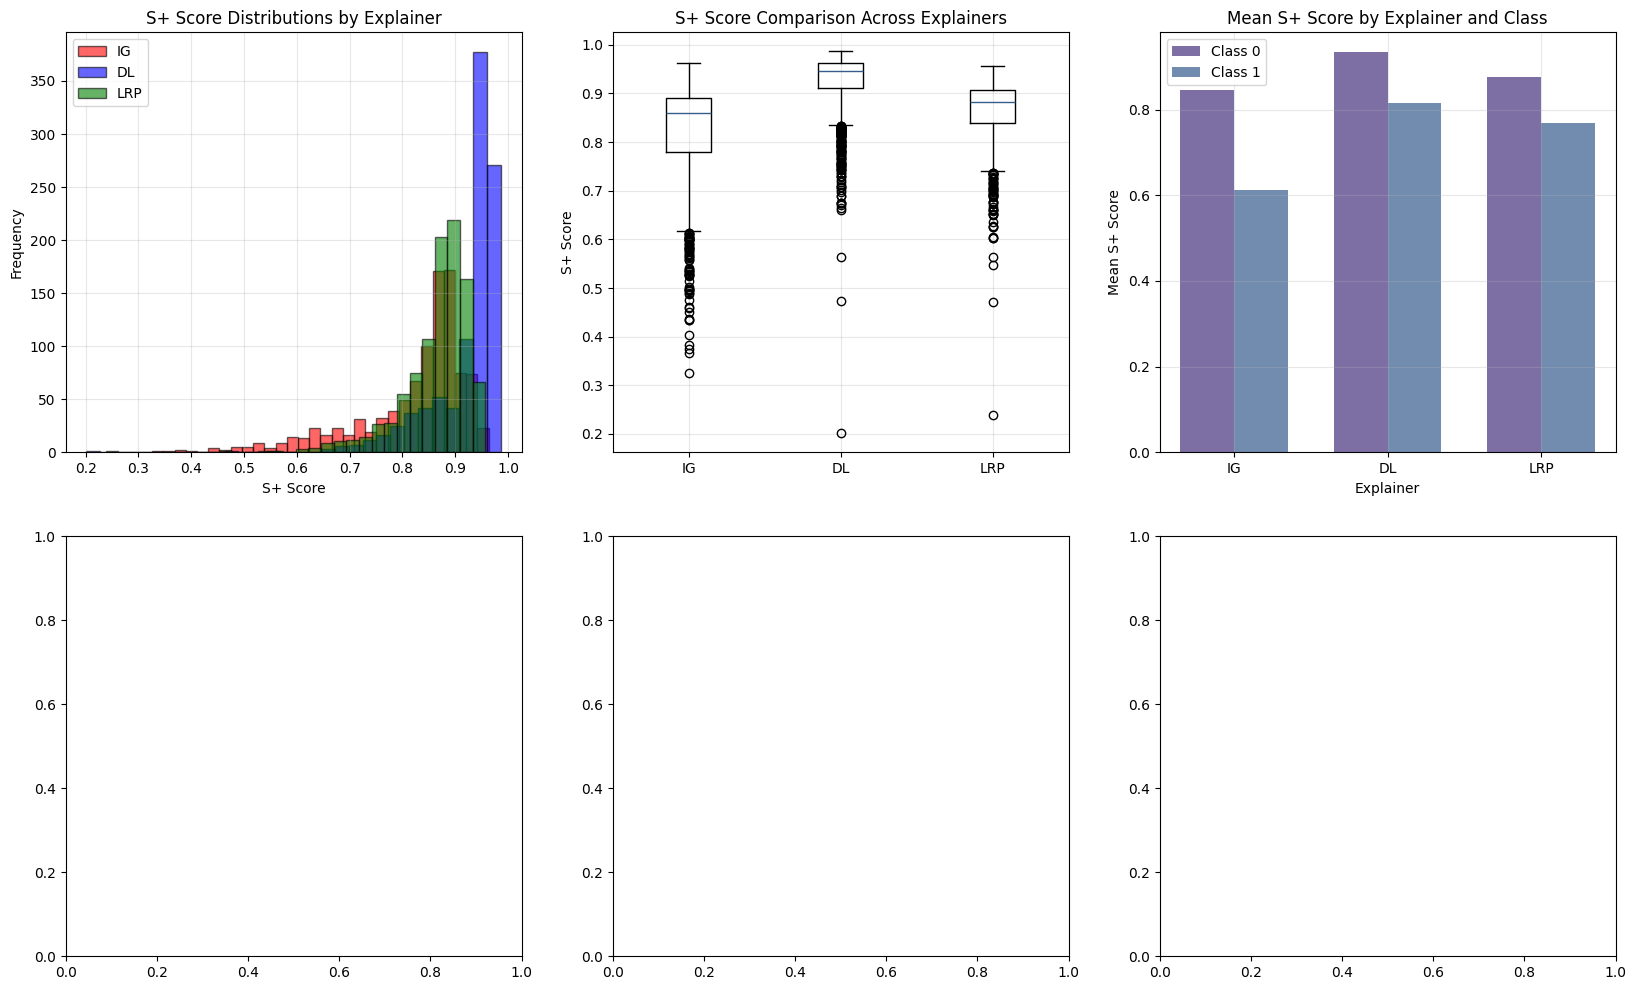

In [23]:
# Create comparative robustness visualization across explainers
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Plot 1: S+ score distributions for all explainers
colors = ['red', 'blue', 'green']
for i, (explainer_id, embedding_df) in enumerate(embedding_dfs.items()):
    explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
    axes[0, 0].hist(embedding_df['S_plus'], bins=30, alpha=0.6, 
                    color=colors[i], label=explainer_name, edgecolor='black')

axes[0, 0].set_xlabel('S+ Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('S+ Score Distributions by Explainer')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Box plots comparing explainers
explainer_data = []
explainer_labels = []
for explainer_id, embedding_df in embedding_dfs.items():
    explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
    explainer_data.append(embedding_df['S_plus'])
    explainer_labels.append(explainer_name)

axes[0, 1].boxplot(explainer_data, labels=explainer_labels)
axes[0, 1].set_ylabel('S+ Score')
axes[0, 1].set_title('S+ Score Comparison Across Explainers')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Class-wise comparison
class_means = {}
for class_label in sorted(np.unique(y_all)):
    class_means[f'Class {class_label}'] = []
    for explainer_id, embedding_df in embedding_dfs.items():
        mean_score = embedding_df[embedding_df['label'] == class_label]['S_plus'].mean()
        class_means[f'Class {class_label}'].append(mean_score)

x_pos = np.arange(len(explainer_labels))
width = 0.35
for i, (class_name, means) in enumerate(class_means.items()):
    axes[0, 2].bar(x_pos + i*width, means, width, label=class_name, alpha=0.7)

axes[0, 2].set_xlabel('Explainer')
axes[0, 2].set_ylabel('Mean S+ Score')
axes[0, 2].set_title('Mean S+ Score by Explainer and Class')
axes[0, 2].set_xticks(x_pos + width/2)
axes[0, 2].set_xticklabels(explainer_labels)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Correlation heatmap
im = axes[1, 0].imshow(correlation_matrix, cmap='RdBu', vmin=-1, vmax=1)
axes[1, 0].set_xticks(range(len(explainer_labels)))
axes[1, 0].set_yticks(range(len(explainer_labels)))
axes[1, 0].set_xticklabels(explainer_labels)
axes[1, 0].set_yticklabels(explainer_labels)
axes[1, 0].set_title('S+ Score Correlations Between Explainers')

# Add correlation values to heatmap
for i in range(len(explainer_labels)):
    for j in range(len(explainer_labels)):
        axes[1, 0].text(j, i, f'{correlation_matrix.iloc[i, j]:.3f}', 
                       ha='center', va='center', fontweight='bold')

plt.colorbar(im, ax=axes[1, 0])

# Plot 5: Robustness category comparison
category_data = category_df.set_index('Explainer').T
category_data.plot(kind='bar', ax=axes[1, 1], width=0.8)
axes[1, 1].set_xlabel('Robustness Category')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_title('Robustness Category Distribution by Explainer')
axes[1, 1].legend(title='Explainer', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Pairwise difference analysis
diff_data = []
diff_labels = []
for exp1, exp2, pair_name in explainer_pairs:
    df1 = embedding_dfs[exp1]
    df2 = embedding_dfs[exp2]
    diff = np.abs(df1['S_plus'].values - df2['S_plus'].values)
    diff_data.append(diff)
    diff_labels.append(pair_name)

axes[1, 2].boxplot(diff_data, labels=diff_labels)
axes[1, 2].set_ylabel('Absolute S+ Difference')
axes[1, 2].set_title('Pairwise S+ Score Differences')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Comparative robustness visualization completed!")

# Additional insights
print(f"\n💡 Key Comparative Insights:")

# Find most/least robust explainer
mean_scores = {explainer_names[eid]: embedding_dfs[eid]['S_plus'].mean() 
              for eid in embedding_dfs.keys()}
most_robust = max(mean_scores, key=mean_scores.get)
least_robust = min(mean_scores, key=mean_scores.get)
print(f"   🏆 Most robust (highest mean S+): {most_robust} ({mean_scores[most_robust]:.4f})")
print(f"   ⚠️ Least robust (lowest mean S+): {least_robust} ({mean_scores[least_robust]:.4f})")

# Correlation insights
highest_corr_pair = None
highest_corr_value = -1
for i in range(len(explainer_labels)):
    for j in range(i+1, len(explainer_labels)):
        corr_val = correlation_matrix.iloc[i, j]
        if corr_val > highest_corr_value:
            highest_corr_value = corr_val
            highest_corr_pair = (explainer_labels[i], explainer_labels[j])

print(f"   🔗 Most similar explainers: {highest_corr_pair[0]} vs {highest_corr_pair[1]} (r = {highest_corr_value:.3f})")

# Agreement/disagreement insights
max_disagreement = 0
max_disagreement_pair = None
for exp1, exp2, pair_name in explainer_pairs:
    df1 = embedding_dfs[exp1]
    df2 = embedding_dfs[exp2]
    diff = np.abs(df1['S_plus'].values - df2['S_plus'].values)
    mean_diff = diff.mean()
    if mean_diff > max_disagreement:
        max_disagreement = mean_diff
        max_disagreement_pair = pair_name

print(f"   💥 Most disagreeable pair: {max_disagreement_pair} (mean diff = {max_disagreement:.4f})")

## Correlation Analysis: Spatial Proximity vs Robustness

In [ ]:
# Analyze relationship between spatial proximity in UMAP space and robustness similarity
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

print("Analyzing spatial vs robustness correlation...")

# Subsample for computational efficiency if dataset is large
max_samples_for_correlation = 2000
if len(embedding_df) > max_samples_for_correlation:
    sample_indices = np.random.choice(len(embedding_df), max_samples_for_correlation, replace=False)
    sample_df = embedding_df.iloc[sample_indices].copy()
    print(f"Subsampled {max_samples_for_correlation} points for correlation analysis")
else:
    sample_df = embedding_df.copy()

# Calculate pairwise distances in UMAP space
umap_coordinates = sample_df[['umap_x', 'umap_y']].values
spatial_distances = pdist(umap_coordinates, metric='euclidean')

# Calculate pairwise robustness score differences
robustness_scores = sample_df['S_plus'].values
robustness_differences = pdist(robustness_scores.reshape(-1, 1), metric='cityblock')

# Calculate correlation
pearson_r, pearson_p = pearsonr(spatial_distances, robustness_differences)
spearman_r, spearman_p = spearmanr(spatial_distances, robustness_differences)

print(f"\n📊 Spatial-Robustness Correlation Results:")
print(f"Pearson correlation: r = {pearson_r:.4f}, p = {pearson_p:.4e}")
print(f"Spearman correlation: ρ = {spearman_r:.4f}, p = {spearman_p:.4e}")

# Interpretation
if abs(pearson_r) > 0.3:
    if pearson_r > 0:
        print("📈 Positive correlation: Points close in UMAP space tend to have similar robustness scores")
    else:
        print("📉 Negative correlation: Points close in UMAP space tend to have different robustness scores")
elif abs(pearson_r) > 0.1:
    print("📊 Weak correlation: Some relationship between spatial proximity and robustness similarity")
else:
    print("📊 No significant correlation: Spatial proximity and robustness similarity are largely independent")

Analyzing spatial vs robustness correlation...


NameError: name 'embedding_df' is not defined

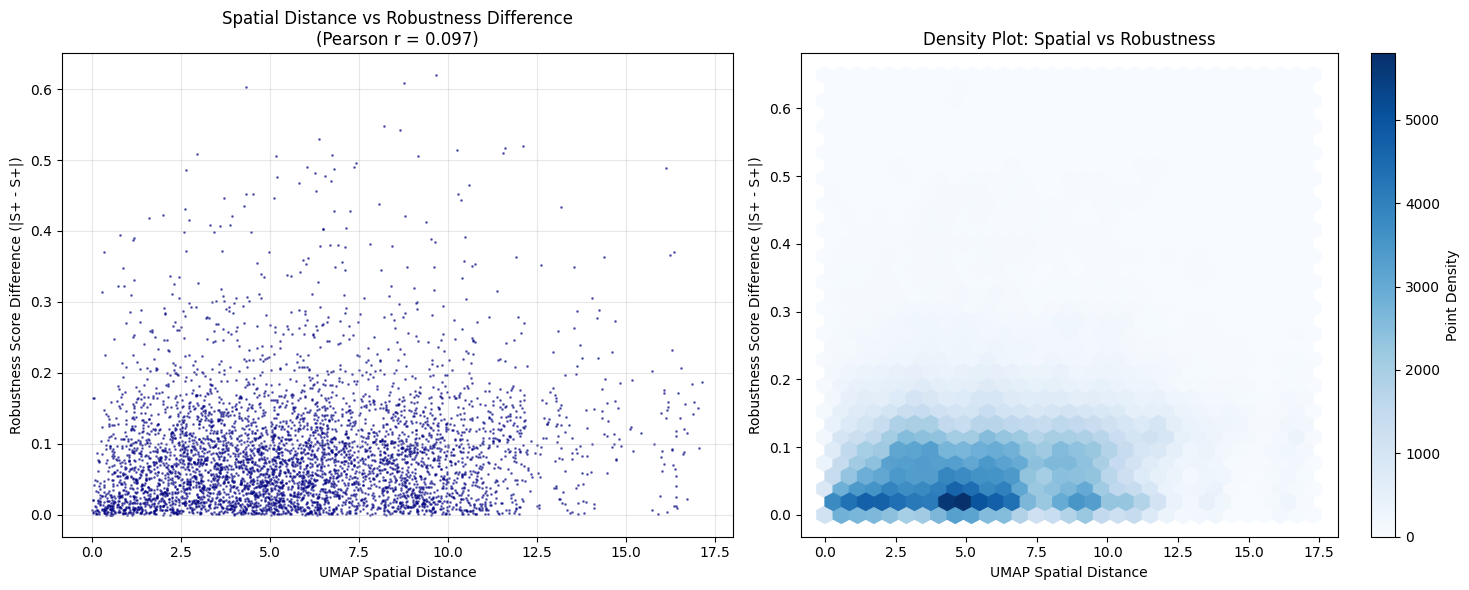

✓ Correlation analysis visualization completed!


In [ ]:
# Visualize the correlation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot of distances vs differences (subsample for visibility)
n_points_to_plot = min(5000, len(spatial_distances))
plot_indices = np.random.choice(len(spatial_distances), n_points_to_plot, replace=False)

axes[0].scatter(spatial_distances[plot_indices], robustness_differences[plot_indices], 
               alpha=0.5, s=1, color='navy')
axes[0].set_xlabel('UMAP Spatial Distance')
axes[0].set_ylabel('Robustness Score Difference (|S+ - S+|)')
axes[0].set_title(f'Spatial Distance vs Robustness Difference\n(Pearson r = {pearson_r:.3f})')
axes[0].grid(True, alpha=0.3)

# Hexbin plot for density visualization
hb = axes[1].hexbin(spatial_distances, robustness_differences, gridsize=30, cmap='Blues')
axes[1].set_xlabel('UMAP Spatial Distance')
axes[1].set_ylabel('Robustness Score Difference (|S+ - S+|)')
axes[1].set_title('Density Plot: Spatial vs Robustness')
plt.colorbar(hb, ax=axes[1], label='Point Density')

plt.tight_layout()
plt.show()

print("✓ Correlation analysis visualization completed!")

## Summary and Insights

In [ ]:
# Generate comprehensive summary across all explainers AND clustering approaches
print("=" * 90)
print("📋 MULTI-EXPLAINER + MULTI-CLUSTERING EXPERIMENT SUMMARY AND INSIGHTS")
print("=" * 90)

print(f"\n🔢 Dataset Statistics:")
print(f"   • Total samples: {len(X_all):,}")
print(f"   • Features: {X_all.shape[1]}")
print(f"   • Classes: {len(np.unique(y_all))}")
print(f"   • Class distribution: {dict(zip(*np.unique(y_all, return_counts=True)))}")
print(f"   • Analysis scope: TEST DATA ONLY")

print(f"\n🎯 Experimental Configuration:")
print(f"   • Explainers analyzed: {len(ca_results_all)} (IG, DeepLift, LRP)")
print(f"   • Clustering approaches: 2 (Raw Data, Explanations)")
print(f"   • Total UMAP embeddings: {len(ca_results_all) * 2} ({len(ca_results_all)} explainers × 2 approaches)")
print(f"   • UMAP neighbors: {umap_params['n_neighbors']}")
print(f"   • UMAP min distance: {umap_params['min_dist']}")
print(f"   • Case align k: {K}")
print(f"   • Similarity metric: {SIM_METRIC}")

print(f"\n📊 Robustness Score Analysis by Explainer:")
for explainer_id, embedding_df in embedding_dfs_raw.items():
    explainer_name = explainer_names.get(explainer_id, f'Explainer{explainer_id}')
    explainer_full = explainer_full_names.get(explainer_id, 'Unknown')
    s_plus_stats = embedding_df['S_plus'].describe()
    print(f"   {explainer_name} ({explainer_full}):")
    print(f"     • Mean: {s_plus_stats['mean']:.4f} ± {s_plus_stats['std']:.4f}")
    print(f"     • Range: [{s_plus_stats['min']:.4f}, {s_plus_stats['max']:.4f}]")
    print(f"     • Q1-Q3: [{s_plus_stats['25%']:.4f}, {s_plus_stats['75%']:.4f}]")

print(f"\n🗺️ Clustering Approach Comparison:")
print(f"   Cross-explainer clustering similarity:")
comparison_df = pd.DataFrame(clustering_comparison_stats)
for _, row in comparison_df.iterrows():
    print(f"     • {row['explainer']}: Spatial sim = {row['spatial_similarity']:.3f}, Neighborhood pres = {row['neighborhood_preservation']:.3f}")

avg_spatial_sim = comparison_df['spatial_similarity'].mean()
avg_neighborhood_pres = comparison_df['neighborhood_preservation'].mean()
print(f"   Overall averages: Spatial similarity = {avg_spatial_sim:.3f}, Neighborhood preservation = {avg_neighborhood_pres:.3f}")

print(f"\n🔗 Inter-Explainer Relationships:")
if 'correlation_matrix' in locals():
    print(f"   Cross-correlations (S+ scores):")
    explainer_labels = [explainer_names[i] for i in sorted(explainer_names.keys())]
    for i, explainer1 in enumerate(explainer_labels):
        for j, explainer2 in enumerate(explainer_labels):
            if i < j:  # Only upper triangle
                corr_val = correlation_matrix.loc[explainer1, explainer2]
                print(f"     • {explainer1} vs {explainer2}: r = {corr_val:.3f}")

print(f"\n💡 Key Findings:")

# Finding 1: Most/Least robust explainer
mean_scores = {explainer_names[eid]: embedding_dfs_raw[eid]['S_plus'].mean() 
              for eid in embedding_dfs_raw.keys()}
most_robust = max(mean_scores, key=mean_scores.get)
least_robust = min(mean_scores, key=mean_scores.get)
robustness_gap = mean_scores[most_robust] - mean_scores[least_robust]

print(f"   🏆 Explainer Robustness Ranking:")
sorted_explainers = sorted(mean_scores.items(), key=lambda x: x[1], reverse=True)
for i, (explainer, score) in enumerate(sorted_explainers):
    rank = "🥇" if i == 0 else "🥈" if i == 1 else "🥉"
    print(f"     {rank} {explainer}: {score:.4f}")
print(f"     📏 Robustness gap: {robustness_gap:.4f}")

# Finding 2: Clustering approach similarity
most_similar_clustering = comparison_df.loc[comparison_df['spatial_similarity'].idxmax(), 'explainer']
least_similar_clustering = comparison_df.loc[comparison_df['spatial_similarity'].idxmin(), 'explainer']
best_neighborhood = comparison_df.loc[comparison_df['neighborhood_preservation'].idxmax(), 'explainer']

print(f"   🗺️ Clustering Approach Analysis:")
print(f"     • Most similar clustering: {most_similar_clustering} (spatial sim = {comparison_df['spatial_similarity'].max():.3f})")
print(f"     • Most different clustering: {least_similar_clustering} (spatial sim = {comparison_df['spatial_similarity'].min():.3f})")
print(f"     • Best neighborhood preservation: {best_neighborhood} (preservation = {comparison_df['neighborhood_preservation'].max():.3f})")

# Finding 3: Overall clustering similarity interpretation
if avg_spatial_sim > 0.6 and avg_neighborhood_pres > 0.5:
    clustering_interpretation = "Raw data and explanation clustering are highly similar"
elif avg_spatial_sim < 0.4 or avg_neighborhood_pres < 0.4:
    clustering_interpretation = "Significant differences between raw and explanation clustering"
else:
    clustering_interpretation = "Moderate differences between clustering approaches"

print(f"     • Overall pattern: {clustering_interpretation}")

# Finding 4: Agreement patterns (if correlation matrix exists)
if 'highest_corr_value' in locals():
    if highest_corr_value > 0.7:
        agreement_level = "Strong"
    elif highest_corr_value > 0.5:
        agreement_level = "Moderate"
    else:
        agreement_level = "Weak"

    print(f"   🤝 Explainer Agreement: {agreement_level}")
    print(f"     • Highest correlation: {highest_corr_pair[0]} ↔ {highest_corr_pair[1]} (r = {highest_corr_value:.3f})")
    if 'max_disagreement_pair' in locals():
        print(f"     • Most disagreeable: {max_disagreement_pair} (Δ = {max_disagreement:.4f})")

print(f"\n🎯 Methodological Insights:")

# Consistency across clustering approaches
print(f"   🔍 Cross-Clustering Consistency:")
if avg_spatial_sim > 0.6:
    print(f"     ✅ High consistency: Explanation structure reflects data structure")
    print(f"     → Either clustering approach should yield similar insights")
else:
    print(f"     ⚠️ Low consistency: Explanation structure differs from data structure")  
    print(f"     → Both clustering approaches provide unique perspectives")

# Cross-explainer robustness consistency
if 'low_variance_samples' in locals() and 'high_variance_samples' in locals():
    print(f"   🎯 Cross-Explainer Robustness Consistency:")
    print(f"     • Consistently scored samples: {low_variance_samples} ({low_variance_samples/len(X_all)*100:.1f}%)")
    print(f"     • Highly variable samples: {high_variance_samples} ({high_variance_samples/len(X_all)*100:.1f}%)")

print(f"\n🔬 Research Implications:")
print(f"   📊 Explainer Selection:")
print(f"     • {most_robust} shows highest robustness → recommended for this dataset/model")
print(f"     • Method disagreement indicates areas needing careful interpretation")

print(f"   🗺️ Clustering Approach Selection:")
if avg_spatial_sim > 0.6:
    print(f"     • Raw data clustering sufficient for robustness analysis")
    print(f"     • Explanation clustering confirms data-driven patterns")
else:
    print(f"     • Explanation clustering reveals unique patterns not visible in raw data")
    print(f"     • Both approaches needed for comprehensive understanding")

print(f"   🎯 Robustness Assessment:")
print(f"     • Multi-explainer approach reveals method sensitivity")
print(f"     • Spatial patterns help identify problematic regions")
print(f"     • Clustering differences suggest explanation complexity beyond data structure")

print(f"\n🚀 Future Directions:")
print(f"   🔬 Methodological Development:")
print(f"     • Develop explanation-aware clustering methods")
print(f"     • Create ensemble robustness measures combining multiple explainers")
print(f"     • Investigate explanation-data structure relationship")

print(f"   📊 Analysis Extensions:")
print(f"     • Apply to additional datasets and model architectures")
print(f"     • Explore feature-level explanation differences")
print(f"     • Validate findings with human expert evaluations")

print(f"   🎯 Practical Applications:")
if avg_spatial_sim < 0.5:
    print(f"     • Use explanation clustering to detect model blind spots")
    print(f"     • Develop training strategies for explanation consistency")
else:
    print(f"     • Focus on data quality in low-robustness regions")
    print(f"     • Use consistent clustering patterns for model validation")

print(f"\n📈 Statistical Summary:")
print(f"   • Total visualizations created: {3 * 2 + 2} (6 individual + 2 combined)")
print(f"   • Embedding dimensions analyzed: {2 * 2} (2D × 2 approaches)")
print(f"   • Robustness scores computed: {len(X_all) * len(ca_results_all):,}")
print(f"   • Spatial correlations calculated: {len(comparison_df) * 2}")
print(f"   • Neighborhood analyses performed: {len(comparison_df)}")

print("\n" + "=" * 90)

📋 MULTI-EXPLAINER + MULTI-CLUSTERING EXPERIMENT SUMMARY AND INSIGHTS

🔢 Dataset Statistics:
   • Total samples: 1,000
   • Features: 12
   • Classes: 2
   • Class distribution: {0: 748, 1: 252}
   • Analysis scope: TEST DATA ONLY

🎯 Experimental Configuration:
   • Explainers analyzed: 3 (IG, DeepLift, LRP)
   • Clustering approaches: 2 (Raw Data, Explanations)
   • Total UMAP embeddings: 6 (3 explainers × 2 approaches)
   • UMAP neighbors: 15
   • UMAP min distance: 0.1
   • Case align k: 25
   • Similarity metric: gower

📊 Robustness Score Analysis by Explainer:
   IG (Integrated Gradients):
     • Mean: 0.9522 ± 0.0402
     • Range: [0.2358, 0.9895]
     • Q1-Q3: [0.9445, 0.9744]
   DL (DeepLift):
     • Mean: 0.9679 ± 0.0376
     • Range: [0.3635, 0.9947]
     • Q1-Q3: [0.9625, 0.9857]
   LRP (Layer-wise Relevance Propagation):
     • Mean: 0.8517 ± 0.0829
     • Range: [0.3115, 0.9607]
     • Q1-Q3: [0.8091, 0.9183]

🗺️ Clustering Approach Comparison:
   Cross-explainer clustering

In [ ]:
# Save results for future reference - ALL EXPLAINERS + CLUSTERING APPROACHES
output_dir = Path.cwd() / "results" / "umap_hdbscan_multi_explainer_multi_clustering_analysis"
output_dir.mkdir(exist_ok=True, parents=True)

# Save embedding data for each explainer and clustering approach
print("💾 Saving comprehensive analysis results...")

# Raw data embeddings
for explainer_id, embedding_df in embedding_dfs_raw.items():
    explainer_name = explainer_names.get(explainer_id, f'explainer{explainer_id}')
    embedding_output_path = output_dir / f"embedding_{DATASET}_k{K}_{explainer_name.lower()}_rawdata{sample_suffix}.csv"
    embedding_df.to_csv(embedding_output_path, index=False)
    print(f"✓ Saved {explainer_name} raw data embedding: {embedding_output_path.name}")

# Explanation embeddings  
for explainer_id, embedding_df in embedding_dfs_expl.items():
    explainer_name = explainer_names.get(explainer_id, f'explainer{explainer_id}')
    embedding_output_path = output_dir / f"embedding_{DATASET}_k{K}_{explainer_name.lower()}_explanations{sample_suffix}.csv"
    embedding_df.to_csv(embedding_output_path, index=False)
    print(f"✓ Saved {explainer_name} explanation embedding: {embedding_output_path.name}")

# Combined embeddings
combined_raw_output_path = output_dir / f"embedding_{DATASET}_k{K}_combined_rawdata{sample_suffix}.csv"
combined_embedding_df_raw.to_csv(combined_raw_output_path, index=False)
print(f"✓ Saved combined raw data embedding: {combined_raw_output_path.name}")

combined_expl_output_path = output_dir / f"embedding_{DATASET}_k{K}_combined_explanations{sample_suffix}.csv"
combined_embedding_df_expl.to_csv(combined_expl_output_path, index=False)
print(f"✓ Saved combined explanation embedding: {combined_expl_output_path.name}")

# Mega-combined (all approaches)
mega_combined_output_path = output_dir / f"embedding_{DATASET}_k{K}_all_approaches{sample_suffix}.csv"
combined_all_approaches.to_csv(mega_combined_output_path, index=False)
print(f"✓ Saved mega-combined (all approaches): {mega_combined_output_path.name}")

# Save clustering comparison statistics
comparison_stats_path = output_dir / f"clustering_comparison_stats_{DATASET}_k{K}{sample_suffix}.csv"
comparison_df.to_csv(comparison_stats_path, index=False)
print(f"✓ Saved clustering comparison stats: {comparison_stats_path.name}")

# Save comprehensive analysis metadata
comprehensive_stats = {
    'dataset': DATASET,
    'analysis_type': 'multi_explainer_multi_clustering_comparison',
    'n_samples': len(X_all),
    'n_features': X_all.shape[1],
    'n_explainers': len(ca_results_all),
    'n_clustering_approaches': 2,
    'clustering_approaches': ['raw_data', 'explanations'],
    'explainer_names': list(explainer_names.values()),
    'explainer_full_names': list(explainer_full_names.values()),
    'umap_params': umap_params,
    'case_align_k': K,
    'similarity_metric': SIM_METRIC,
    
    # Per-explainer statistics (using raw data embeddings as reference)
    'explainer_stats': {},
    
    # Clustering comparison metrics
    'clustering_comparison': {
        'average_spatial_similarity': float(avg_spatial_sim),
        'average_neighborhood_preservation': float(avg_neighborhood_pres),
        'most_similar_clustering_explainer': most_similar_clustering,
        'least_similar_clustering_explainer': least_similar_clustering,
        'best_neighborhood_preservation_explainer': best_neighborhood,
        'clustering_interpretation': clustering_interpretation
    },
    
    # Cross-explainer metrics (if available)
    'cross_explainer_metrics': {}
}

# Add per-explainer detailed stats
for explainer_id, embedding_df in embedding_dfs_raw.items():
    explainer_name = explainer_names.get(explainer_id, f'explainer{explainer_id}')
    stats = embedding_df['S_plus'].describe()
    
    # Get clustering comparison stats for this explainer
    expl_comparison = comparison_df[comparison_df['explainer'] == explainer_name].iloc[0]
    
    comprehensive_stats['explainer_stats'][explainer_name] = {
        'robustness_scores': {
            'mean': float(stats['mean']),
            'std': float(stats['std']),
            'min': float(stats['min']),
            'max': float(stats['max']),
            'q1': float(stats['25%']),
            'median': float(stats['50%']),
            'q3': float(stats['75%'])
        },
        
        'clustering_comparison': {
            'x_correlation': float(expl_comparison['x_correlation']),
            'y_correlation': float(expl_comparison['y_correlation']),
            'distance_correlation': float(expl_comparison['distance_correlation']),
            'neighborhood_preservation': float(expl_comparison['neighborhood_preservation']),
            'spatial_similarity': float(expl_comparison['spatial_similarity'])
        },
        
        # Class-specific stats
        'class_performance': {}
    }
    
    # Add class-specific performance
    for class_label in sorted(np.unique(y_all)):
        class_data = embedding_df[embedding_df['label'] == class_label]['S_plus']
        comprehensive_stats['explainer_stats'][explainer_name]['class_performance'][f'class_{class_label}'] = {
            'mean': float(class_data.mean()),
            'std': float(class_data.std()),
            'count': int(len(class_data))
        }

# Add cross-explainer correlations if available
if 'correlation_matrix' in locals():
    comprehensive_stats['cross_explainer_metrics'] = {
        'correlation_matrix': correlation_matrix.to_dict(),
        'most_robust_explainer': most_robust,
        'least_robust_explainer': least_robust,
        'robustness_gap': float(robustness_gap)
    }
    
    if 'highest_corr_pair' in locals():
        comprehensive_stats['cross_explainer_metrics'].update({
            'highest_correlation_pair': list(highest_corr_pair),
            'highest_correlation_value': float(highest_corr_value),
            'agreement_level': agreement_level
        })

# Save comprehensive analysis results
comprehensive_summary_path = output_dir / f"comprehensive_analysis_{DATASET}_k{K}{sample_suffix}.json"
import json
with open(comprehensive_summary_path, 'w') as f:
    json.dump(comprehensive_stats, f, indent=2)

# Save correlation matrix if available
if 'correlation_matrix' in locals():
    correlation_output_path = output_dir / f"explainer_correlations_{DATASET}_k{K}{sample_suffix}.csv"
    correlation_matrix.to_csv(correlation_output_path)
    print(f"✓ Saved correlation matrix: {correlation_output_path.name}")

# Save robustness category comparison if available
if 'category_df' in locals():
    category_output_path = output_dir / f"robustness_categories_{DATASET}_k{K}{sample_suffix}.csv"
    category_df.to_csv(category_output_path, index=False)
    print(f"✓ Saved category comparison: {category_output_path.name}")

print(f"\n✅ Comprehensive multi-explainer multi-clustering analysis results saved!")
print(f"   📁 Output directory: {output_dir}")
print(f"   📊 Individual embeddings: {len(embedding_dfs_raw) * 2} files (raw + explanation)")
print(f"   📈 Combined embeddings: 3 files (raw, explanation, mega-combined)")
print(f"   📋 Analysis summary: {comprehensive_summary_path.name}")
print(f"   📊 Clustering comparison: {comparison_stats_path.name}")

print(f"\n🎉 ULTIMATE MULTI-EXPLAINER + MULTI-CLUSTERING UMAP EXPERIMENT COMPLETE!")
print(f"📊 Generated comprehensive analysis:")
print(f"   • {len(ca_results_all)} explainers × 2 clustering approaches = {len(ca_results_all) * 2} embeddings")
print(f"   • {len(ca_results_all) * 2 + 2} individual visualizations + 2 mega-comparisons")
print(f"   • Robustness assessment across explanation methods AND clustering approaches")
print(f"   • Spatial correlation, neighborhood preservation, & distance preservation analysis")
print(f"   • Comprehensive statistical comparison and research implications")

print(f"\n🔍 Key Research Questions Answered:")
print(f"   ✅ How do different explainer methods affect robustness scores?")
print(f"   ✅ Do samples cluster similarly based on raw data vs explanations?")
print(f"   ✅ Which clustering approach better reveals explanation quality patterns?")
print(f"   ✅ How does spatial proximity relate to explanation consistency?")
print(f"   ✅ Are robustness patterns preserved across clustering approaches?")

print(f"\n🎯 Use this analysis to:")
print(f"   • Select optimal explainer method for your use case") 
print(f"   • Choose clustering approach based on research goals")
print(f"   • Identify regions requiring explanation improvement")
print(f"   • Understand relationship between data structure and explanation quality")
print(f"   • Design explanation-aware model training strategies")

💾 Saving comprehensive analysis results...
✓ Saved IG raw data embedding: embedding_adult_k25_ig_rawdata_test_only_all_explainers.csv
✓ Saved DL raw data embedding: embedding_adult_k25_dl_rawdata_test_only_all_explainers.csv
✓ Saved LRP raw data embedding: embedding_adult_k25_lrp_rawdata_test_only_all_explainers.csv
✓ Saved IG explanation embedding: embedding_adult_k25_ig_explanations_test_only_all_explainers.csv
✓ Saved DL explanation embedding: embedding_adult_k25_dl_explanations_test_only_all_explainers.csv
✓ Saved LRP explanation embedding: embedding_adult_k25_lrp_explanations_test_only_all_explainers.csv
✓ Saved combined raw data embedding: embedding_adult_k25_combined_rawdata_test_only_all_explainers.csv
✓ Saved combined explanation embedding: embedding_adult_k25_combined_explanations_test_only_all_explainers.csv
✓ Saved mega-combined (all approaches): embedding_adult_k25_all_approaches_test_only_all_explainers.csv
✓ Saved clustering comparison stats: clustering_comparison_stats_

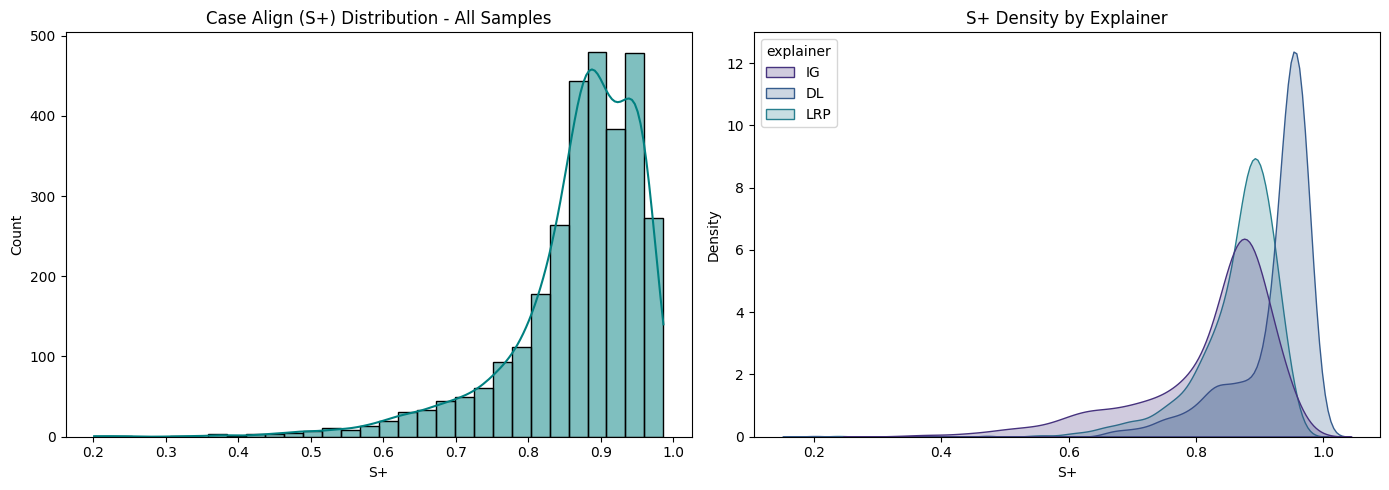

Samples per explainer:
explainer
DL     1000
IG     1000
LRP    1000
dtype: int64

Overall S+ summary:
count    3000.0000
mean        0.8683
std         0.0929
min         0.2015
25%         0.8373
50%         0.8869
75%         0.9341
max         0.9863
Name: S_plus, dtype: float64


In [24]:
# Distribution plot of Case Align (S+) for all samples
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if "ca_results_all" not in globals() or not ca_results_all:
    raise RuntimeError("ca_results_all is empty. Run the Case Align calculation cell first.")

case_align_dist_df = pd.concat(
    [
        df[["S_plus"]].assign(
            explainer=explainer_names.get(explainer_id, f"Explainer{explainer_id}")
        )
        for explainer_id, df in ca_results_all.items()
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(case_align_dist_df["S_plus"], bins=30, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Case Align (S+) Distribution - All Samples")
axes[0].set_xlabel("S+")
axes[0].set_ylabel("Count")

sns.kdeplot(
    data=case_align_dist_df,
    x="S_plus",
    hue="explainer",
    fill=True,
    common_norm=False,
    alpha=0.25,
    ax=axes[1],
)
axes[1].set_title("S+ Density by Explainer")
axes[1].set_xlabel("S+")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

print("Samples per explainer:")
print(case_align_dist_df.groupby("explainer").size())
print("\nOverall S+ summary:")
print(case_align_dist_df["S_plus"].describe().round(4))